In [7]:
import torch
import numpy as np
import time
from torch.utils.data import DataLoader

from data_generation_oddball import generate_oddball_data
from datasets_oddball import ICLOddballDataset, collate_fn_oddball
from models import MatrixTreeMarkovICLOddball, MLPICLOddball
from training_oddball import train_models_joint_oddball
from evaluation_oddball import test_sphere_oddball

# ============================================================
# Data Parameters
# ============================================================
task_geometry = "sphere"   # or "line" (alias) or "sphere"
N = 3                 # context length (= number of classes L)
D = 2                 # feature dimension
perturb_dist = 5.0    # oddball perturbation distance d
center_bound = 10.0    # cluster center mu ~ Uniform([-B, B]^D)
cluster_std = 1.0     # isotropic noise std around mu
seed = 5

# ============================================================
# Model / Training Parameters
# ============================================================
add_mlp = True
n_nodes = 20
transform_func = "exp"
learn_base_rates = True
rate_encoder_type = "linear"
encoder_mlp_depth = 2
encoder_mlp_width = 32
rate_decoder_type = "linear"
decoder_mlp_depth = 2
decoder_mlp_width = 32

mlp_baseline_depth = 4
mlp_baseline_width = 64
mlp_baseline_dropout = 0.0
mlp_baseline_activation = "relu"

sparsity_rho_edge = 1.0
sparsity_rho_all = 1.0
sparsity_rho_edge_base_W = 1.0
base_mask_value = float("-inf")

epochs = 50
lr = 0.025
batch_size = 100
train_samples = 20000
val_samples = 5000
method = "direct_solve"
temperature = 1.0
eval_frequency = 10
n_eval_samples = 500
ood_distances = [1.0, 2.0, 5.0, 10.0, 20.0]
train_on_varied_distances = True

params = {
    "N": N,
    "D": D,
    "L": N,
    "perturb_dist": perturb_dist,
    "center_bound": center_bound,
    "cluster_std": cluster_std,
    "seed": seed,
    "add_mlp": add_mlp,
    "n_nodes": n_nodes,
    "transform_func": transform_func,
    "learn_base_rates": learn_base_rates,
    "rate_encoder_type": rate_encoder_type,
    "encoder_mlp_depth": encoder_mlp_depth,
    "encoder_mlp_width": encoder_mlp_width,
    "rate_decoder_type": rate_decoder_type,
    "decoder_mlp_depth": decoder_mlp_depth,
    "decoder_mlp_width": decoder_mlp_width,
    "epochs": epochs,
    "lr": lr,
    "batch_size": batch_size,
    "train_samples": train_samples,
    "val_samples": val_samples,
    "method": method,
    "temperature": temperature,
    "task_geometry": task_geometry,
    "ood_distances": ood_distances,
    "train_on_varied_distances": train_on_varied_distances,
}

print("=" * 70)
print(f"MARKOV ICL - {task_geometry.upper()} ODDBALL")
print("=" * 70)
print(f"N={N}, D={D}, geometry={task_geometry}, d={perturb_dist}")
print("=" * 70)
print(f"N={N}, D={D}, L=N={N}, d={perturb_dist}, center_bound={center_bound}")
if train_on_varied_distances:
    print(f"Training on varied distances: {list(ood_distances)[:5]}...{list(ood_distances)[-1]}")
else:
    print(f"Training on fixed distance: {perturb_dist}")
print(f"Method={method}, temperature={temperature}")
print("=" * 70)

torch.manual_seed(seed)
np.random.seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}\n")

print(f"Generating {task_geometry} oddball data...")
train_data = generate_oddball_data(
    n_samples=train_samples,
    N=N, D=D,
    perturb_dist=perturb_dist,
    center_bound=center_bound,
    cluster_std=cluster_std,
    seed=seed,
    task_geometry=task_geometry,
    perturb_dist_range=ood_distances if train_on_varied_distances else None,
)
val_data = generate_oddball_data(
    n_samples=val_samples,
    N=N, D=D,
    perturb_dist=perturb_dist,
    center_bound=center_bound,
    cluster_std=cluster_std,
    task_geometry=task_geometry,
    perturb_dist_range=ood_distances if train_on_varied_distances else None,
)

train_loader = DataLoader(
    ICLOddballDataset(train_data),
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_fn_oddball,
)
val_loader = DataLoader(
    ICLOddballDataset(val_data),
    batch_size=batch_size,
    collate_fn=collate_fn_oddball,
)

markov_model = MatrixTreeMarkovICLOddball(
    n_nodes=n_nodes,
    z_dim=D,
    N=N,
    learn_base_rates=learn_base_rates,
    transform_func=transform_func,
    sparsity_rho_edge=sparsity_rho_edge,
    sparsity_rho_all=sparsity_rho_all,
    sparsity_rho_edge_base_W=sparsity_rho_edge_base_W,
    base_mask_value=base_mask_value,
    rate_encoder_type=rate_encoder_type,
    encoder_mlp_depth=encoder_mlp_depth,
    encoder_mlp_width=encoder_mlp_width,
    rate_decoder_type=rate_decoder_type,
    decoder_mlp_depth=decoder_mlp_depth,
    decoder_mlp_width=decoder_mlp_width,
)

models_to_train = {"markov": markov_model}
if add_mlp:
    models_to_train["mlp"] = MLPICLOddball(
        z_dim=D,
        N=N,
        depth=mlp_baseline_depth,
        hidden_width=mlp_baseline_width,
        dropout=mlp_baseline_dropout,
        activation=mlp_baseline_activation,
    )

start_time = time.time()
print("\nTraining...")
print("=" * 70)
history = train_models_joint_oddball(
    models=models_to_train,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    n_epochs=epochs,
    lr=lr,
    method=method,
    temperature=temperature,
    N=N,
    D=D,
    perturb_dist=perturb_dist,
    center_bound=center_bound,
    cluster_std=cluster_std,
    task_geometry=task_geometry,
    eval_frequency=eval_frequency,
    n_eval_samples=n_eval_samples,
    ood_distances=ood_distances,
)

results = {}
for name, model in models_to_train.items():
    torch.manual_seed(seed)
    np.random.seed(seed)
    results[name] = test_sphere_oddball(
        model,
        N,
        D,
        device,
        n_samples=1000,
        train_dist=perturb_dist,
        test_distances=ood_distances,
        center_bound=center_bound,
        cluster_std=cluster_std,
        task_geometry=task_geometry,
        method=method,
        temperature=temperature,
    )

end_time = time.time()
print(f"Training time: {end_time - start_time:.2f} seconds")

MARKOV ICL - SPHERE ODDBALL
N=3, D=2, geometry=sphere, d=5.0
N=3, D=2, L=N=3, d=5.0, center_bound=10.0
Training on varied distances: [1.0, 2.0, 5.0, 10.0, 20.0]...20.0
Method=direct_solve, temperature=1.0
Device: cpu

Generating sphere oddball data...
  Initialized Markov ICL Oddball model (N=3, L=3, z_dim=2)
  Rate encoder: linear
  Rate decoder: linear
  Parameters: 2,860
  Initialized MLP ICL Oddball model (N=3, z_dim=2, depth=4, width=64, activation=relu, dropout=0.0)
  Parameters: 8,963

Training...
Epoch  10 | MARKOV Train/Val: 75.86%/76.92% | MLP Train/Val: 76.11%/77.32% | MARKOV OOD@train_d: 89.80% | MLP OOD@train_d: 92.40%
Epoch  20 | MARKOV Train/Val: 75.91%/75.28% | MLP Train/Val: 76.40%/77.74% | MARKOV OOD@train_d: 88.00% | MLP OOD@train_d: 92.40%
Epoch  30 | MARKOV Train/Val: 76.00%/76.18% | MLP Train/Val: 76.59%/77.28% | MARKOV OOD@train_d: 90.00% | MLP OOD@train_d: 90.00%
Epoch  40 | MARKOV Train/Val: 76.06%/76.02% | MLP Train/Val: 76.90%/76.42% | MARKOV OOD@train_d: 91.

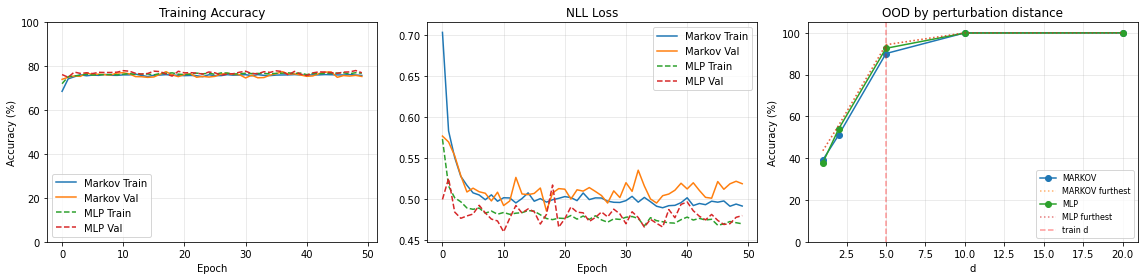

In [8]:
try:
    import matplotlib.pyplot as plt

    h_m = history["markov"]
    h_mlp = history.get("mlp")

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    ax1 = axes[0]
    ax1.plot(h_m["train_acc"], label="Markov Train")
    ax1.plot(h_m["val_acc"], label="Markov Val")
    if h_mlp is not None:
        ax1.plot(h_mlp["train_acc"], "--", label="MLP Train")
        ax1.plot(h_mlp["val_acc"], "--", label="MLP Val")
    ax1.set_title("Training Accuracy")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Accuracy (%)")
    ax1.set_ylim([0, 100])
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    ax2 = axes[1]
    ax2.plot(h_m["train_loss"], label="Markov Train")
    ax2.plot(h_m["val_loss"], label="Markov Val")
    if h_mlp is not None:
        ax2.plot(h_mlp["train_loss"], "--", label="MLP Train")
        ax2.plot(h_mlp["val_loss"], "--", label="MLP Val")
    ax2.set_title("NLL Loss")
    ax2.set_xlabel("Epoch")
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    ax3 = axes[2]
    for name in results.keys():
        dists = sorted(results[name]["by_distance"].keys())
        accs = [results[name]["by_distance"][d] for d in dists]
        ax3.plot(dists, accs, "o-", label=name.upper())
        baseline = [results[name]["furthest_point_baseline"][d] for d in dists]
        ax3.plot(dists, baseline, ":", alpha=0.6, label=f"{name.upper()} furthest")
    ax3.axvline(x=perturb_dist, color="r", linestyle="--", alpha=0.4, label="train d")
    ax3.set_title("OOD by perturbation distance")
    ax3.set_xlabel("d")
    ax3.set_ylabel("Accuracy (%)")
    ax3.set_ylim([0, 105])
    ax3.grid(True, alpha=0.3)
    ax3.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

except ImportError:
    print("(Install matplotlib to see training plots)")

RuntimeError: einsum(): subscript d has size 6 for operand 1 which does not broadcast with previously seen size 3

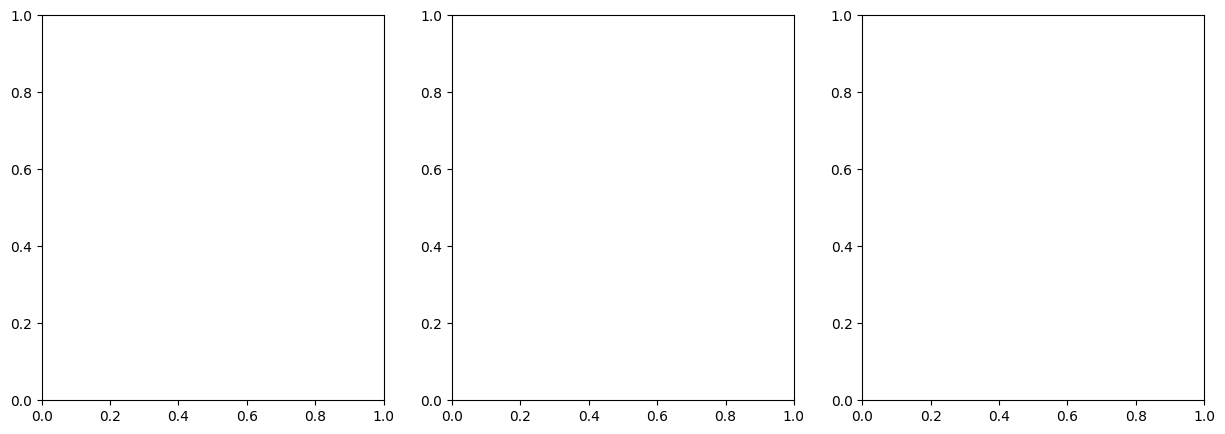

In [6]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def plot_oddball_grid(
    model,
    data,
    device="cpu",
    method="direct_solve",
    temperature=1.0,
    seed=None,
    nrows=2,
    ncols=3,
    figsize=None,
):
    """
    Plot a grid of oddball episodes.

    Args:
        model: the model to use for predictions
        data: list of (z_context, target), where target is 1-indexed
        device: device to run the model on
        method: prediction method
        temperature: temperature for prediction
        seed: random seed for episode selection
        nrows: number of subplot rows
        ncols: number of subplot columns
        figsize: tuple, optional, size for plt.subplots

    Returns:
        fig, axes: matplotlib Figure and Axes objects
    """
    n_episodes = nrows * ncols
    if len(data) < n_episodes:
        raise ValueError(f"Need at least {n_episodes} episodes in `data`.")

    rng = np.random.default_rng(seed)
    idxs = rng.choice(len(data), size=n_episodes, replace=False)

    if figsize is None:
        # scale width with columns, height with rows
        figsize = (5 * ncols, 5 * nrows)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.array(axes).reshape(-1)  # flatten in case axes is 2d or 1d

    model.eval()
    with torch.no_grad():
        for ax, data_idx in zip(axes, idxs):
            z_context, target = data[data_idx]
            if not torch.is_tensor(z_context):
                z_context = torch.tensor(z_context, dtype=torch.float32)

            # predict oddball (0-based)
            log_probs = model(
                z_context.unsqueeze(0).to(device),
                method=method,
                temperature=temperature
            )
            pred_idx = int(log_probs.argmax(dim=1).item())
            true_idx = int(target) - 1

            z = z_context.detach().cpu().numpy()

            # all points
            ax.scatter(z[:, 0], z[:, 1], c="lightgray", s=90, edgecolor="k", label="points")

            # predicted oddball
            ax.scatter(
                z[pred_idx, 0], z[pred_idx, 1],
                c="crimson", s=220, marker="o", edgecolor="k", linewidth=1.3, label="pred"
            )

            # true oddball
            ax.scatter(
                z[true_idx, 0], z[true_idx, 1],
                c="dodgerblue", s=200, marker="X", edgecolor="k", linewidth=1.0, label="true"
            )

            # annotate indices
            for i, (x, y) in enumerate(z):
                ax.text(x + 0.03, y + 0.03, str(i), fontsize=9)

            ok = pred_idx == true_idx
            ax.set_title(f"episode {data_idx} | pred={pred_idx} true={true_idx} | {'OK' if ok else 'MISS'}")
            ax.set_aspect("equal", adjustable="box")
            ax.grid(alpha=0.25)
            ax.set_xlabel("x1")
            ax.set_ylabel("x2")
            ax.set_xlim(-15, 15)
            ax.set_ylim(-15, 15)

    # one shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    return fig, axes


import numpy as np
import torch

seed = 5
np.random.seed(seed)
torch.manual_seed(seed)

# Example:
test_data = generate_sphere_oddball_data(
    n_samples=200, N=N, D=2, perturb_dist=5.0, center_bound=center_bound, cluster_std=cluster_std
)
fig, axes = plot_oddball_grid(
    markov_model,
    test_data,
    device=device,
    method=method,
    temperature=temperature,
    seed=0,
    nrows=1,
    ncols=3,
    # figsize=(14, 10)  # optional
)
plt.show()

In [8]:
import numpy as np
import torch
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# --- knobs ---
N, D = 3, 1
x_range = (-10.0, 10.0)   # range for each of the 3 scalar inputs
grid_n = 40               # increase for smoother surfaces, decrease for speed
colorscale = "Viridis"

# plane style
plane_opacity = 0.50
plane_color = "gray"

# --- build 3D input grid: (x1, x2, x3) ---
x1 = np.linspace(*x_range, grid_n, dtype=np.float32)
x2 = np.linspace(*x_range, grid_n, dtype=np.float32)
x3 = np.linspace(*x_range, grid_n, dtype=np.float32)
X1, X2, X3 = np.meshgrid(x1, x2, x3, indexing="ij")

# flatten -> model batch: (flat, N, D) = (flat, 3, 1)
flat = X1.size
z_batch_np = np.stack([X1.ravel(), X2.ravel(), X3.ravel()], axis=1)  # (flat, 3)
z_batch = torch.from_numpy(z_batch_np).unsqueeze(-1)                 # (flat, 3, 1)

# --- model forward ---
model.eval()
with torch.no_grad():
    out = model(z_batch.to(device), method=method, temperature=temperature)  # (flat, 3)
    probs = torch.softmax(out, dim=1).cpu().numpy()  # works for logits or log-probs

# reshape class probabilities onto grid
P1 = probs[:, 0].reshape(grid_n, grid_n, grid_n)  # p(label=1)
P2 = probs[:, 1].reshape(grid_n, grid_n, grid_n)  # p(label=2)
P3 = probs[:, 2].reshape(grid_n, grid_n, grid_n)  # p(label=3)

# --- visualize: one 3D contour/isosurface panel per class ---
fig = make_subplots(
    rows=1,
    cols=3,
    specs=[[{"type": "scene"}, {"type": "scene"}, {"type": "scene"}]],
    subplot_titles=("P(label=1)", "P(label=2)", "P(label=3)"),
    horizontal_spacing=0.03,
)

common_iso = dict(
    x=X1.ravel(),
    y=X2.ravel(),
    z=X3.ravel(),
    isomin=0.05,          # contour lower bound
    isomax=0.95,          # contour upper bound
    surface_count=8,      # number of contour levels
    opacity=0.35,
    caps=dict(x_show=False, y_show=False, z_show=False),
    colorscale=colorscale,
    cmin=0.0,
    cmax=1.0,
)

fig.add_trace(
    go.Isosurface(value=P1.ravel(), showscale=False, **common_iso),
    row=1, col=1
)
fig.add_trace(
    go.Isosurface(value=P2.ravel(), showscale=False, **common_iso),
    row=1, col=2
)
fig.add_trace(
    go.Isosurface(
        value=P3.ravel(),
        showscale=True,
        colorbar=dict(title="probability", len=0.75, x=1.02, tickformat=".2f"),
        **common_iso
    ),
    row=1, col=3
)

# --- add low-opacity reference planes x1=x2, x1=x3, x2=x3 to each panel ---
u = np.linspace(*x_range, 35)
v = np.linspace(*x_range, 35)
U, V = np.meshgrid(u, v, indexing="ij")

# Define unique colors for each plane
plane_color_x1eqx2 = "#1f77b4"  # blue
plane_color_x1eqx3 = "#2ca02c"  # green
plane_color_x2eqx3 = "#d62728"  # red
plane_opacity = 0.50

# x1 = x2  ->  (x, x, z)
plane_x1eqx2 = dict(
    x=U, y=U, z=V,
    showscale=False,
    opacity=plane_opacity,
    surfacecolor=np.zeros_like(U),
    colorscale=[[0, plane_color_x1eqx2], [1, plane_color_x1eqx2]],
    hoverinfo="skip",
)

# x1 = x3  ->  (x, y, x)
plane_x1eqx3 = dict(
    x=U, y=V, z=U,
    showscale=False,
    opacity=plane_opacity,
    surfacecolor=np.zeros_like(U),
    colorscale=[[0, plane_color_x1eqx3], [1, plane_color_x1eqx3]],
    hoverinfo="skip",
)

# x2 = x3  ->  (x, y, y)
plane_x2eqx3 = dict(
    x=V, y=U, z=U,
    showscale=False,
    opacity=plane_opacity,
    surfacecolor=np.zeros_like(U),
    colorscale=[[0, plane_color_x2eqx3], [1, plane_color_x2eqx3]],
    hoverinfo="skip",
)

# for c in [1, 2, 3]:
#     fig.add_trace(go.Surface(**plane_x1eqx2), row=1, col=c)
#     fig.add_trace(go.Surface(**plane_x1eqx3), row=1, col=c)
#     fig.add_trace(go.Surface(**plane_x2eqx3), row=1, col=c)

# camera = dict(
#     eye=dict(x=1.6, y=1.6, z=1.0),   # where you view from
#     center=dict(x=0.0, y=0.0, z=0.0),# look-at offset
#     up=dict(x=0.0, y=0.0, z=1.0),    # which axis is "up"
# )
# for c in [1, 2, 3]:
#     fig.update_scenes(
#         camera=camera,
#         row=1, col=c
#     )

# fig.add_trace(go.Surface(**plane_x2eqx3), row=1, col=1)
# fig.add_trace(go.Surface(**plane_x1eqx3), row=1, col=2)
# fig.add_trace(go.Surface(**plane_x1eqx2), row=1, col=3)

for c in [1, 2, 3]:
    fig.update_scenes(
        xaxis_title="input 1",
        yaxis_title="input 2",
        zaxis_title="input 3",
        aspectmode="cube",
        row=1, col=c
    )

fig.update_layout(
    title="Class-probability contours in 3D input space (N=3, D=1)",
    height=520,
    margin=dict(l=0, r=70, t=60, b=0),
)
fig.show()

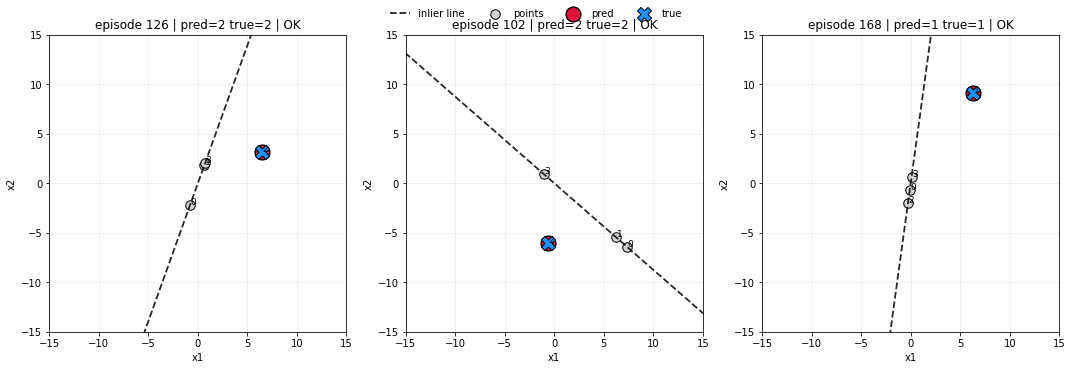

In [34]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def _fit_line_from_points(points_2d):
    """
    Fit line via PCA/SVD.
    Returns (center, direction_unit).
    """
    c = points_2d.mean(axis=0)
    X = points_2d - c
    # principal direction
    _, _, vh = np.linalg.svd(X, full_matrices=False)
    v = vh[0]
    v = v / (np.linalg.norm(v) + 1e-12)
    return c, v

def _line_segment_from_center_dir(center, direction, xlim, ylim):
    """
    Build a long segment clipped by plot ranges for drawing.
    """
    # choose a long t-range based on plot extent
    span = max(xlim[1] - xlim[0], ylim[1] - ylim[0]) * 1.5
    t = np.array([-span, span])
    pts = center[None, :] + t[:, None] * direction[None, :]
    return pts[:, 0], pts[:, 1]

def plot_hyperplane_oddball_grid(
    model,
    data,
    device="cpu",
    method="direct_solve",
    temperature=1.0,
    seed=None,
    nrows=2,
    ncols=3,
    figsize=None,
    xlim=(-15, 15),
    ylim=(-15, 15),
):
    """
    Grid plot for hyperplane oddball in D=2 (line oddball).
    `data` is list of (z_context, target) with target 1-indexed.
    """
    n_episodes = nrows * ncols
    if len(data) < n_episodes:
        raise ValueError(f"Need at least {n_episodes} episodes in `data`.")

    rng = np.random.default_rng(seed)
    idxs = rng.choice(len(data), size=n_episodes, replace=False)

    if figsize is None:
        figsize = (5 * ncols, 5 * nrows)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    model.eval()
    with torch.no_grad():
        for ax, data_idx in zip(axes, idxs):
            z_context, target = data[data_idx]
            if not torch.is_tensor(z_context):
                z_context = torch.tensor(z_context, dtype=torch.float32)

            z = z_context.detach().cpu().numpy()  # (N, 2)
            if z.shape[1] != 2:
                raise ValueError("This plotter expects D=2 so the hyperplane is a line.")

            true_idx = int(target) - 1

            # model prediction (0-based)
            log_probs = model(
                z_context.unsqueeze(0).to(device),
                method=method,
                temperature=temperature
            )
            pred_idx = int(log_probs.argmax(dim=1).item())

            # fit line from true inliers (all points except true oddball)
            inlier_mask = np.ones(len(z), dtype=bool)
            inlier_mask[true_idx] = False
            inliers = z[inlier_mask]
            center, direction = _fit_line_from_points(inliers)
            lx, ly = _line_segment_from_center_dir(center, direction, xlim, ylim)

            # draw line
            ax.plot(lx, ly, "--", color="black", linewidth=1.8, alpha=0.85, label="inlier line")

            # draw all points
            ax.scatter(z[:, 0], z[:, 1], c="lightgray", s=90, edgecolor="k", label="points")

            # predicted oddball
            ax.scatter(
                z[pred_idx, 0], z[pred_idx, 1],
                c="crimson", s=220, marker="o", edgecolor="k", linewidth=1.3, label="pred"
            )

            # true oddball
            ax.scatter(
                z[true_idx, 0], z[true_idx, 1],
                c="dodgerblue", s=200, marker="X", edgecolor="k", linewidth=1.0, label="true"
            )

            for i, (x, y) in enumerate(z):
                ax.text(x + 0.05, y + 0.05, str(i), fontsize=9)

            ok = pred_idx == true_idx
            ax.set_title(f"episode {data_idx} | pred={pred_idx} true={true_idx} | {'OK' if ok else 'MISS'}")
            ax.set_aspect("equal", adjustable="box")
            ax.grid(alpha=0.25)
            ax.set_xlabel("x1")
            ax.set_ylabel("x2")
            ax.set_xlim(*xlim)
            ax.set_ylim(*ylim)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    return fig, axes

# Example (hyperplane oddball in D=2):
test_data = generate_oddball_data(
    n_samples=200, N=N, D=2, perturb_dist=perturb_dist,
    center_bound=center_bound, cluster_std=cluster_std,
    task_geometry="hyperplane"
)
fig, axes = plot_hyperplane_oddball_grid(
    markov_model, test_data, device=device, method=method, temperature=temperature,
    seed=0, nrows=1, ncols=3, xlim=(-15, 15), ylim=(-15, 15)
)
plt.show()